In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm
from scipy.signal import find_peaks

In [4]:
def draw_orbit(m, n, theta, phi, fname = None):
    ff = np.abs(np.real(sph_harm(m, n, theta, phi)))
    ff /= np.max(ff)
    
    # zeros = np.where(np.diff(np.sign(np.diff(ff))) > 0)[0]
    zeros = find_peaks(np.diff(np.sign(np.diff(ff))))[0]
    theta_zeros = thetas[zeros]
    
    fig, ax = plt.subplots(figsize = (0.6, 0.6), subplot_kw={'projection': 'polar'})
    # ax.plot(thetas, ff, c = "k", lw = 0.5)
    
    for i in range(len(theta_zeros)):
        if i == 0:
            start = 0
        else:
            start = zeros[i - 1]
        end = zeros[i]
        if i%2 == 0:
            c = "C0"
        else:
            c = "C2"
        ax.fill_between(thetas[start:end], ff[start:end], color = c, lw = 0.5)
    ax.axis('off')
    
    fig.tight_layout()
    if fname:
        fig.savefig(fname + ".svg", transparent = True)
        fig.savefig(fname + ".png", transparent = True, dpi = 300)

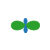

In [5]:
npts = 1000
thetas = np.linspace(-0.5*np.pi, 2*np.pi, npts*10)
draw_orbit(0, 2, np.pi/10, thetas, fname = "fleuron-0")

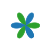

In [6]:
thetas = np.linspace(-0.5*np.pi, 2*np.pi, npts*10)
draw_orbit(3, 3, thetas, np.pi/10, fname = "fleuron-1")

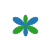

In [7]:
thetas = np.linspace(-0.5*np.pi, 2*np.pi, npts*100)
draw_orbit(1, 3, np.pi/4, thetas, fname = "fleuron-2")

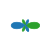

In [8]:
thetas = np.linspace(-0.5*np.pi, 2*np.pi, npts*10)
draw_orbit(0, 3, np.pi/10, thetas, fname = "fleuron-3")